kernel: indigene-sam2

In [1]:
import cv2
import os
import torch
import numpy as np
import skimage as ski
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from itertools import cycle
from src_segmentation.SAM2UNet import SAM2UNet
from torchvision import transforms
import torchvision.transforms.functional as F
import torch.nn.functional as nnF
import random
from tqdm import tqdm
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_holes
from scipy.ndimage import binary_fill_holes

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
class ToTensor(object):
    def __call__(self, data):
        image = data['image']
        return {'image': F.to_tensor(image)}


class Resize(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, data):
        image = data['image']

        return {'image': F.resize(image, self.size)}


class FullDataset(Dataset):
    def __init__(self, 
                 image_root, 
                #  gt_root, 
                 size, 
                 mode
                ):
        self.images = [image_root + f for f in os.listdir(image_root) if f.endswith('.jpg') or f.endswith('.png') or f.endswith('.tif')]
        # self.gts = [gt_root + f for f in os.listdir(gt_root) if f.endswith('.png') or f.endswith('.tif')]
        self.images = sorted(self.images)
        self.images_nameonly = [os.path.splitext(os.path.basename(f))[0] for f in self.images]
        # self.gts = sorted(self.gts)
        if mode == 'train':
            self.transform = transforms.Compose([
                Resize((size, size)),
                # RandomHorizontalFlip(p=0.5),
                # RandomVerticalFlip(p=0.5),
                ToTensor(),
                # Normalize()
            ])
        else:
            self.transform = transforms.Compose([
                Resize((size, size)),
                ToTensor(),
                # Normalize()
            ])

    def __getitem__(self, idx):
        image = self.rgb_loader(self.images[idx])
        # label = self.binary_loader(self.gts[idx])
        # data = {'image': image, 'label': label}
        data = {'image': image}
        data = self.transform(data)
        return data, self.images_nameonly[idx]

    def __len__(self):
        return len(self.images)

    def rgb_loader(self, path):
        with open(path, 'rb') as f:
            img = ski.util.img_as_ubyte(ski.io.imread(f))
            img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
            return img

In [ ]:
# Segment all of the F0 images
dataset = FullDataset("/nfs/research/birney/users/esther/medaka-ziram/data/f0/brightfield/", 
                      352, 
                      mode='test')
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=15, pin_memory = True)
model = SAM2UNet("/nfs/research/birney/users/esther/sam2/checkpoints/sam2_hiera_large.pt").to(device)

In [ ]:
# Segment F0 + F2 validation images
dataset = FullDataset("/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/val/", 
                      size=352, 
                      mode='test')
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=1, pin_memory = True)
model = SAM2UNet("/nfs/research/birney/users/esther/sam2/checkpoints/sam2_hiera_large.pt").to(device)

In [192]:
dataset[0][1]

'WE00001---A001--PO01--LO001--CO6--SL001--PX32500--PW0100--IN0020--TM250--X014463--Y011163--Z211270--T2936162510'

In [6]:
model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/SAM_checkpoints/"
model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")

model.load_state_dict(model_ckpt,
                      strict=True)
model.eval()

/tmp/ipykernel_2374882/4227923369.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")


SAM2UNet(
  (encoder): Hiera(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 144, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    )
    (blocks): Sequential(
      (0): Adapter(
        (block): MultiScaleBlock(
          (norm1): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (attn): MultiScaleAttention(
            (qkv): Linear(in_features=144, out_features=432, bias=True)
            (proj): Linear(in_features=144, out_features=144, bias=True)
          )
          (drop_path): Identity()
          (norm2): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (mlp): MLP(
            (layers): ModuleList(
              (0): Linear(in_features=144, out_features=576, bias=True)
              (1): Linear(in_features=576, out_features=144, bias=True)
            )
            (act): GELU(approximate='none')
          )
        )
        (prompt_learn): Sequential(
          (0): Linear(in_features=144, out_features=32, bias=True)
          (1):

In [11]:
dataset[0][0]

{'image': tensor([[[0.6863, 0.6863, 0.6824,  ..., 0.7176, 0.7176, 0.7137],
          [0.6980, 0.6980, 0.6980,  ..., 0.7294, 0.7294, 0.7255],
          [0.6941, 0.6980, 0.6941,  ..., 0.7294, 0.7294, 0.7255],
          ...,
          [0.3255, 0.2863, 0.2275,  ..., 0.1922, 0.1843, 0.1490],
          [0.3333, 0.3255, 0.2784,  ..., 0.1961, 0.1922, 0.1569],
          [0.3451, 0.3294, 0.3176,  ..., 0.1961, 0.1922, 0.1490]],
 
         [[0.6863, 0.6863, 0.6824,  ..., 0.7176, 0.7176, 0.7137],
          [0.6980, 0.6980, 0.6980,  ..., 0.7294, 0.7294, 0.7255],
          [0.6941, 0.6980, 0.6941,  ..., 0.7294, 0.7294, 0.7255],
          ...,
          [0.3255, 0.2863, 0.2275,  ..., 0.1922, 0.1843, 0.1490],
          [0.3333, 0.3255, 0.2784,  ..., 0.1961, 0.1922, 0.1569],
          [0.3451, 0.3294, 0.3176,  ..., 0.1961, 0.1922, 0.1490]],
 
         [[0.6863, 0.6863, 0.6824,  ..., 0.7176, 0.7176, 0.7137],
          [0.6980, 0.6980, 0.6980,  ..., 0.7294, 0.7294, 0.7255],
          [0.6941, 0.6980, 0.69

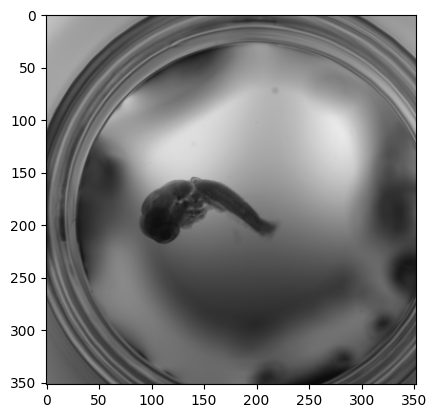

In [24]:
idx = 2
sample_0 = dataset[idx][0]['image']

plt.imshow(sample_0.permute(1,2,0).detach().cpu())

In [25]:
pred0, pred1, pred2 = model(sample_0.unsqueeze(0).to(device))

In [26]:
pred0 = nnF.upsample(pred0, size=(352, 352), mode='bilinear', align_corners=False)
pred0 = pred0.sigmoid().data.cpu().numpy().squeeze()
pred0 = (pred0 - pred0.min()) / (pred0.max() - pred0.min() + 1e-8)
pred0 = (pred0 * 255).astype(np.uint8)

/tmp/ipykernel_2374882/1936123294.py:1: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  pred0 = nnF.upsample(pred0, size=(352, 352), mode='bilinear', align_corners=False)


In [27]:
pred = torch.sigmoid(model(sample_0.unsqueeze(0).to(device))[0])

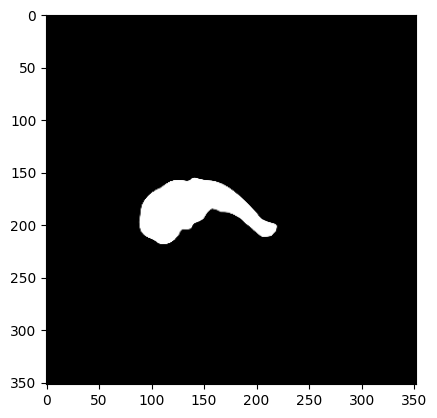

In [28]:
plt.imshow(pred[0].squeeze(0).detach().cpu(), cmap="gray")

In [195]:
batch = next(iter(dataloader))

In [196]:
batch[0]

{'image': tensor([[[[0.4510, 0.4549, 0.4588,  ..., 0.4745, 0.4745, 0.4745],
           [0.4627, 0.4667, 0.4667,  ..., 0.4863, 0.4863, 0.4824],
           [0.4667, 0.4667, 0.4627,  ..., 0.4784, 0.4824, 0.4784],
           ...,
           [0.3294, 0.3373, 0.3412,  ..., 0.3216, 0.3216, 0.3176],
           [0.3255, 0.3333, 0.3333,  ..., 0.3216, 0.3216, 0.3176],
           [0.3176, 0.3255, 0.3255,  ..., 0.3176, 0.3176, 0.3137]],
 
          [[0.4510, 0.4549, 0.4588,  ..., 0.4745, 0.4745, 0.4745],
           [0.4627, 0.4667, 0.4667,  ..., 0.4863, 0.4863, 0.4824],
           [0.4667, 0.4667, 0.4627,  ..., 0.4784, 0.4824, 0.4784],
           ...,
           [0.3294, 0.3373, 0.3412,  ..., 0.3216, 0.3216, 0.3176],
           [0.3255, 0.3333, 0.3333,  ..., 0.3216, 0.3216, 0.3176],
           [0.3176, 0.3255, 0.3255,  ..., 0.3176, 0.3176, 0.3137]],
 
          [[0.4510, 0.4549, 0.4588,  ..., 0.4745, 0.4745, 0.4745],
           [0.4627, 0.4667, 0.4667,  ..., 0.4863, 0.4863, 0.4824],
           [0.4

### Write output masks (F0)

In [201]:
# Load all F0 brighfield data
dataset = FullDataset("/nfs/research/birney/users/esther/medaka-ziram/data/f0/brightfield/", 
                      352, 
                      mode='test')
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=15, pin_memory = True)
model = SAM2UNet("/nfs/research/birney/users/esther/sam2/checkpoints/sam2_hiera_large.pt").to(device)

model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/SAM_checkpoints/"
model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")

model.load_state_dict(model_ckpt,
                      strict=True)
model.eval()

/tmp/ipykernel_717756/2582373564.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")


SAM2UNet(
  (encoder): Hiera(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 144, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    )
    (blocks): Sequential(
      (0): Adapter(
        (block): MultiScaleBlock(
          (norm1): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (attn): MultiScaleAttention(
            (qkv): Linear(in_features=144, out_features=432, bias=True)
            (proj): Linear(in_features=144, out_features=144, bias=True)
          )
          (drop_path): Identity()
          (norm2): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (mlp): MLP(
            (layers): ModuleList(
              (0): Linear(in_features=144, out_features=576, bias=True)
              (1): Linear(in_features=576, out_features=144, bias=True)
            )
            (act): GELU(approximate='none')
          )
        )
        (prompt_learn): Sequential(
          (0): Linear(in_features=144, out_features=32, bias=True)
          (1):

In [ ]:
output_dir = "/nfs/research/birney/users/esther/medaka-ziram/data/f0/annotations_brightfield_unet_regionprops/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for batch in tqdm(dataloader):
    x = batch[0]['image'].to(device)
    # print(i)
    img_name = batch[1][0]
    # print(img_name)
    pred = F.to_pil_image(torch.sigmoid(model(x)[0])[0].squeeze(0).detach().cpu())
    # mask = torch.sigmoid(model(x)[0])[0].squeeze(0).detach().cpu()

    # labeled = label(mask)

    # regions = regionprops(labeled)

    # if regions:
    #     largest_region = max(regions, key=lambda r: r.area)
    #     largest_mask = labeled == largest_region.label
    # else:
    #     largest_mask = np.zeros_like(mask, dtype=bool)

    # largest_mask = binary_fill_holes(largest_mask)
    # result = F.to_pil_image((largest_mask * 255).astype(np.uint8))

    with open(output_dir + "/" + img_name + ".png", "wb") as f:
        pred.save(f, format="PNG")

    # plt.imshow(, cmap="gray")
    # plt.savefig(output_dir + "/" + img_name + ".png", bbox_inches='tight')

 47%|████▋     | 543/1149 [00:28<00:32, 18.77it/s]


KeyboardInterrupt: 

### Write output masks (F0 + F2 validation set)

In [29]:
# Load all validation data
dataset = FullDataset("/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/val/", 
                      352, 
                      mode='test')
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=1, pin_memory = True)
model = SAM2UNet("/nfs/research/birney/users/esther/sam2/checkpoints/sam2_hiera_large.pt").to(device)

model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/SAM_checkpoints/"
model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")

model.load_state_dict(model_ckpt,
                      strict=True)
model.eval()


output_dir = "/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/val_seg/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for batch in tqdm(dataloader):
    x = batch[0]['image'].to(device)
    # print(i)
    img_name = batch[1][0]
    # print(img_name)
    pred = F.to_pil_image(torch.sigmoid(model(x)[0])[0].squeeze(0).detach().cpu())

    with open(output_dir + "/" + img_name + ".png", "wb") as f:
        pred.save(f, format="PNG")


/tmp/ipykernel_2374882/222070515.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")
100%|██████████| 408/408

### Write output masks (F2 test set)

In [30]:
# Load all test data
dataset = FullDataset("/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/test/", 
                      352, 
                      mode='test')
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=1, pin_memory = True)
model = SAM2UNet("/nfs/research/birney/users/esther/sam2/checkpoints/sam2_hiera_large.pt").to(device)

model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/SAM_checkpoints/"
model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")

model.load_state_dict(model_ckpt,
                      strict=True)
model.eval()


output_dir = "/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/test_seg/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for batch in tqdm(dataloader):
    x = batch[0]['image'].to(device)
    # print(i)
    img_name = batch[1][0]
    # print(img_name)
    pred = F.to_pil_image(torch.sigmoid(model(x)[0])[0].squeeze(0).detach().cpu())

    with open(output_dir + "/" + img_name + ".png", "wb") as f:
        pred.save(f, format="PNG")

/tmp/ipykernel_2374882/2855104942.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "best_model_epoch-197.pth")
100%|██████████| 2150/2